<a href="https://colab.research.google.com/github/luccasnn/pipeline-dados/blob/main/pipeline_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# instala dependências
!pip install schedule sqlalchemy -q

import pandas as pd
import numpy as np
import requests
import sqlite3
import logging
import time
from datetime import datetime
from sqlalchemy import create_engine

# registra tudo que acontece no pipeline
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
log = logging.getLogger(__name__)

print("dependências instaladas!")

dependências instaladas!


In [3]:
# etapa 1 — coleta de dados
def coletar_dados():
    log.info("iniciando coleta de dados...")

    try:
        # coleta dados reais de criptomoedas via API
        url = "https://api.coingecko.com/api/v3/coins/markets"
        params = {
            "vs_currency": "usd",
            "order": "market_cap_desc",
            "per_page": 20,
            "page": 1
        }
        resposta = requests.get(url, params=params, timeout=10)
        dados = resposta.json()

        df = pd.DataFrame(dados)[['id', 'symbol', 'name', 'current_price',
                                   'market_cap', 'price_change_percentage_24h',
                                   'total_volume']]
        df['coletado_em'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        log.info(f"coletados {len(df)} registros com sucesso")
        return df

    except Exception as e:
        log.error(f"erro na coleta: {e}")
        return None

# etapa 2 — limpeza
def limpar_dados(df):
    log.info("iniciando limpeza...")

    antes = len(df)
    df = df.dropna()
    df = df[df['current_price'] > 0]
    df = df[df['total_volume'] > 0]
    df['price_change_percentage_24h'] = df['price_change_percentage_24h'].round(2)

    log.info(f"limpeza concluída — {antes} → {len(df)} registros")
    return df

# etapa 3 — armazenamento
def salvar_dados(df):
    log.info("salvando no banco de dados...")

    engine = create_engine('sqlite:///cripto.db')
    df.to_sql('precos', engine, if_exists='append', index=False)

    log.info("dados salvos com sucesso!")
    return True

# executa o pipeline completo
def executar_pipeline():
    log.info("=== PIPELINE INICIADO ===")

    df = coletar_dados()
    if df is None:
        log.error("pipeline abortado — falha na coleta")
        return

    df = limpar_dados(df)
    salvar_dados(df)

    log.info("=== PIPELINE CONCLUÍDO ===")
    return df

# roda uma vez
df_resultado = executar_pipeline()
df_resultado.head()

,id,symbol,name,current_price,market_cap,price_change_percentage_24h,total_volume,coletado_em
0,bitcoin,btc,Bitcoin,65792.000000,1319491027876,0.04,25544784924,2026-06-17 03:04:47
1,ethereum,eth,Ethereum,1791.850000,216329689989,1.28,14777172486,2026-06-17 03:04:47
2,tether,usdt,Tether,0.999102,186374481210,-0.03,49455884228,2026-06-17 03:04:47
3,binancecoin,bnb,BNB,604.280000,81470043260,-1.21,993543124,2026-06-17 03:04:47
4,ripple,xrp,XRP,1.220000,75568618679,-0.01,1784520316,2026-06-17 03:04:47


In [4]:
import schedule

# agenda o pipeline para rodar a cada 1 minuto (demo)
schedule.every(1).minutes.do(executar_pipeline)

print("pipeline agendado — rodando a cada 1 minuto")
print("aguarda 2 execuções automáticas...\n")

# roda por 2 minutos e para
contador = 0
while contador < 2:
    schedule.run_pending()
    time.sleep(60)
    contador += 1
    print(f"execução {contador} concluída")

print("\npipeline finalizado!")

pipeline agendado — rodando a cada 1 minuto
aguarda 2 execuções automáticas...

execução 1 concluída
execução 2 concluída

pipeline finalizado!


In [5]:
# consulta o banco e analisa o histórico
engine = create_engine('sqlite:///cripto.db')

df_historico = pd.read_sql('SELECT * FROM precos', engine)

print(f"total de registros no banco: {len(df_historico)}")
print(f"execuções registradas: {df_historico['coletado_em'].nunique()}")
print(f"\ntop 5 por market cap:")
print(df_historico.sort_values('market_cap', ascending=False).head()[['name', 'current_price', 'price_change_percentage_24h']])

total de registros no banco: 40
execuções registradas: 2

top 5 por market cap:
        name  current_price  price_change_percentage_24h
0    Bitcoin   65792.000000                         0.04
20   Bitcoin   65804.000000                         0.10
1   Ethereum    1791.850000                         1.28
21  Ethereum    1792.060000                         1.19
2     Tether       0.999102                        -0.03


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

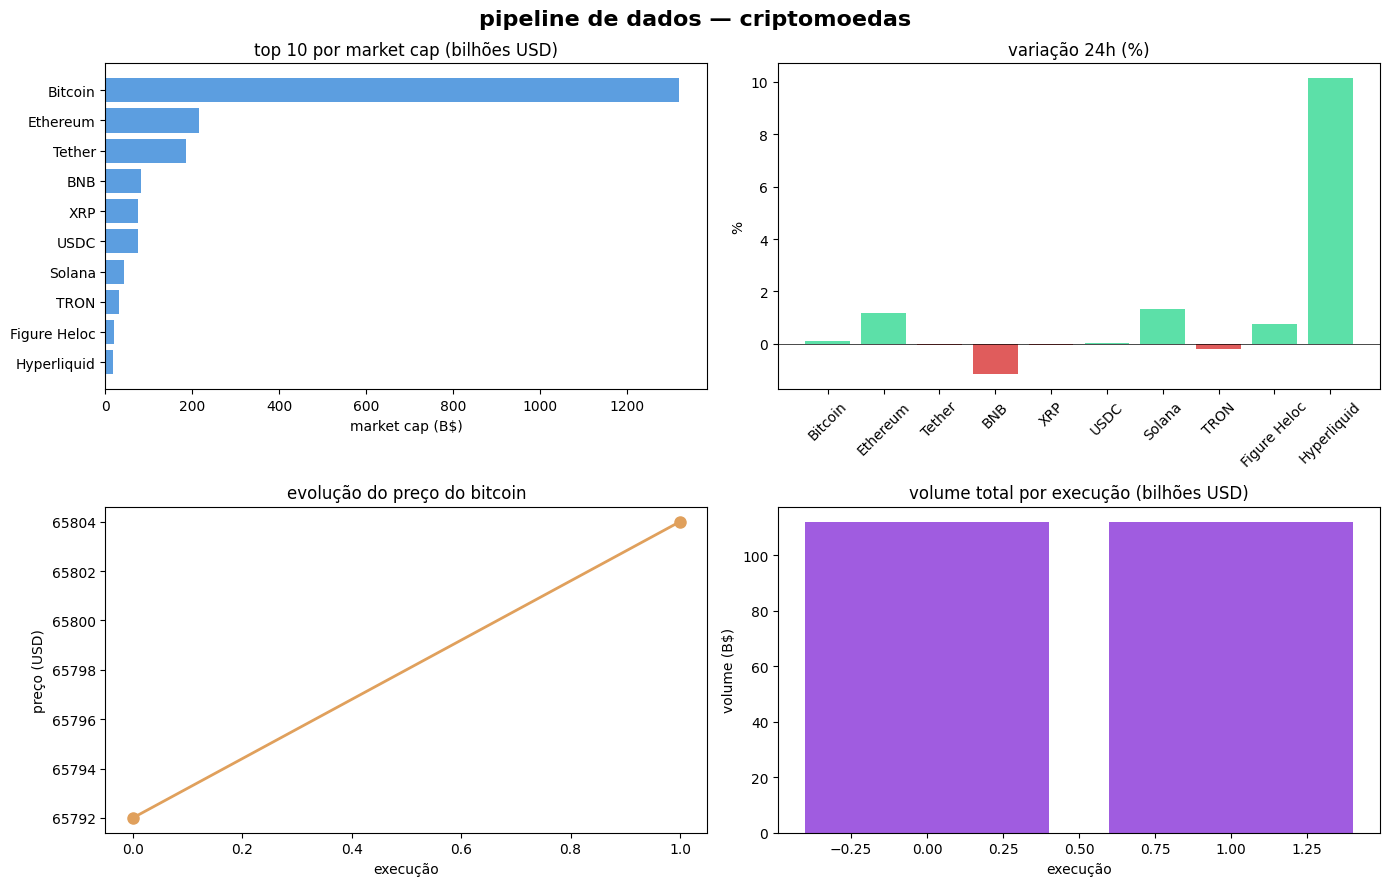

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('pipeline de dados — criptomoedas', fontsize=16, fontweight='bold')

# top 10 por market cap
ultima_coleta = df_historico[df_historico['coletado_em'] == df_historico['coletado_em'].max()]
top10 = ultima_coleta.nlargest(10, 'market_cap')

axes[0, 0].barh(top10['name'], top10['market_cap'] / 1e9, color='#5c9ee0')
axes[0, 0].set_title('top 10 por market cap (bilhões USD)')
axes[0, 0].set_xlabel('market cap (B$)')
axes[0, 0].invert_yaxis()

# variação 24h
cores = ['#5ce0a8' if x > 0 else '#e05c5c' for x in top10['price_change_percentage_24h']]
axes[0, 1].bar(top10['name'], top10['price_change_percentage_24h'], color=cores)
axes[0, 1].set_title('variação 24h (%)')
axes[0, 1].set_ylabel('%')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=0, color='black', linewidth=0.5)

# evolução do bitcoin entre execuções
btc = df_historico[df_historico['name'] == 'Bitcoin']
axes[1, 0].plot(range(len(btc)), btc['current_price'],
                marker='o', color='#e0a05c', linewidth=2, markersize=8)
axes[1, 0].set_title('evolução do preço do bitcoin')
axes[1, 0].set_xlabel('execução')
axes[1, 0].set_ylabel('preço (USD)')

# volume total por execução
volume_por_execucao = df_historico.groupby('coletado_em')['total_volume'].sum()
axes[1, 1].bar(range(len(volume_por_execucao)),
               volume_por_execucao.values / 1e9, color='#a05ce0')
axes[1, 1].set_title('volume total por execução (bilhões USD)')
axes[1, 1].set_xlabel('execução')
axes[1, 1].set_ylabel('volume (B$)')

plt.tight_layout()
plt.savefig('pipeline_dados.png', dpi=150, bbox_inches='tight')

from google.colab import files
files.download('pipeline_dados.png')
plt.show()